### 24RB1075 小嶋将太郎

### 演習１

In [363]:
import numpy as np
import matplotlib.pyplot as plt

N = 100
D = np.random.randn(N, 2)

# クラスごとにデータを生成
X_plus  = D + np.array([1,1])
X_minus = D + np.array([-1,1])

# クラスラベル
y_plus  =  np.ones(N)
y_minus = -np.ones(N)

X = np.vstack([X_plus, X_minus])
y = np.hstack([y_plus, y_minus])

In [364]:
def soft_margin_loss(X, y, w, b, C):
    z = y * (X @ w + b)
    hinge = np.maximum(0, 1 - z)
    reg = 0.5 * np.dot(w, w)
    loss = reg + C * np.sum(hinge)
    return loss


In [365]:
def soft_margin_loss_grad(X, y, w, b, C):
    z = y * (X @ w + b)
    hinge = np.maximum(0, 1 - z)
    dw =  w - C * np.sum(y[hinge > 0, None] * X[hinge > 0], axis=0)
    db =  - C * np.sum(y[hinge > 0])
    return dw, db

In [366]:
C = 0.8
eta = 0.001
epochs = 1000

w = np.array([0.0, 0.0])
b = 0.0

losses = []

w_log = []
b_log = []

for epoch in range(epochs):
    current_loss = soft_margin_loss(X, y, w, b, C)
    losses.append(current_loss)

    dw, db = soft_margin_loss_grad(X, y, w, b, C)
    w = w - eta * dw
    b = b - eta * db

    if epoch == 1:
        w_log.append(w.copy())
        b_log.append(b)

    if epoch == epochs // 2:
        w_log.append(w.copy())
        b_log.append(b)
    if epoch == epochs - 1:
        w_log.append(w.copy())
        b_log.append(b)


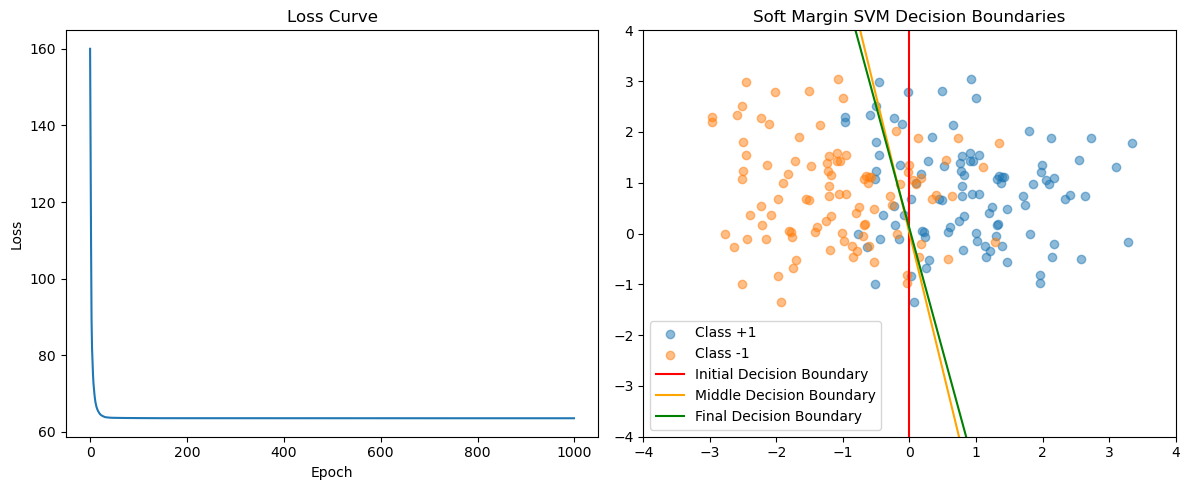

In [367]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(losses)
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.scatter(X_plus[:, 0], X_plus[:, 1], label='Class +1', alpha=0.5)
plt.scatter(X_minus[:, 0], X_minus[:, 1], label='Class -1', alpha=0.5)

X_line = np.linspace(-3, 3, 100)
labels = ['Initial', 'Middle', 'Final']
colors = ['red', 'orange', 'green']

for i in range(3):
    w_i = w_log[i]
    b_i = b_log[i]

    if w_i[1] != 0:
        y_line = - (w_i[0] * X_line + b_i) / w_i[1]
        plt.plot(X_line, y_line, label=f'{labels[i]} Decision Boundary', color=colors[i])

plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.title('Soft Margin SVM Decision Boundaries')
plt.legend()

plt.tight_layout()
plt.show()

### 演習２



In [368]:
theta = np.linspace(0, 2 * np.pi, N)

r1 = 1.0
r2 = 2.0


X_c1 = np.column_stack([r1 * np.cos(theta) + 0.1 * np.random.randn(N), r1 * np.sin(theta) + 0.1 * np.random.randn(N)])
X_c2 = np.column_stack([r2 * np.cos(theta) + 0.1 * np.random.randn(N), r2 * np.sin(theta) + 0.1 * np.random.randn(N)])

y_c1 = np.ones(N)
y_c2 = -np.ones(N)

X_c = np.vstack([X_c1, X_c2])
y_c = np.hstack([y_c1, y_c2])

In [369]:
def phi(X):

    x1 = X[:,0]
    x2 = X[:,1]
    return (x1**2 + x2**2).reshape(-1, 1)

X_phi = phi(X_c)

In [370]:
C = 0.8
eta = 0.001
epochs = 1000

w = np.array(X_phi.shape[1]*[0.0])
b = 0.0

losses = []

w_log = []
b_log = []

for epoch in range(epochs):
    current_loss = soft_margin_loss(X_phi, y_c, w, b, C)
    losses.append(current_loss)

    dw, db = soft_margin_loss_grad(X_phi, y_c, w, b, C)
    w = w - eta * dw
    b = b - eta * db

    if epoch == 1:
        w_log.append(w.copy())
        b_log.append(b)

    if epoch == epochs // 2:
        w_log.append(w.copy())
        b_log.append(b)
    if epoch == epochs - 1:
        w_log.append(w.copy())
        b_log.append(b)


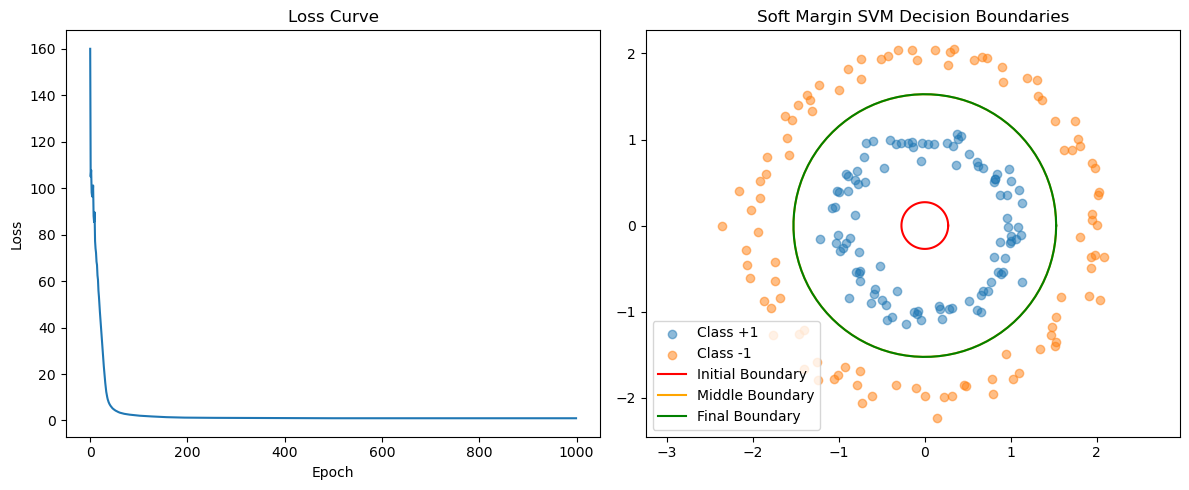

In [371]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(losses)
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.scatter(X_c1[:, 0], X_c1[:, 1], label='Class +1', alpha=0.5)
plt.scatter(X_c2[:, 0], X_c2[:, 1], label='Class -1', alpha=0.5)

theta_boundary = np.linspace(0, 2 * np.pi, 100)
labels = ['Initial', 'Middle', 'Final']
colors = ['red', 'orange', 'green']

for i in range(3):
    w_i = w_log[i]
    b_i = b_log[i]

    if w_i[0] != 0 and -b_i / w_i[0] > 0:

        r = np.sqrt(-b_i / w_i[0])

        x_circle = r * np.cos(theta_boundary)
        y_circle = r * np.sin(theta_boundary)

        plt.plot(
            x_circle,
            y_circle,
            label=f'{labels[i]} Boundary',
            color=colors[i]
        )

plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.axis('equal')
plt.title('Soft Margin SVM Decision Boundaries')
plt.legend()

plt.tight_layout()
plt.show()

### 考察
損失曲線により、学習初期段階に損失が急激に減少することが確認できた。これは初期のパラメータが0であり、多くのデータがマージン条件を満たしておらず、勾配が大きくなったからである。学習が進むにつれ正しく分類されるデータが増え、更新量が次第に小さくなるため、中期と最後では分類境界の変化もほとんど見られなかった。

### AIの使用
損失関数の実装の最終確認および、損失関数と分類境界の描画方法の理解に活用した。